# Segunda clase semana 14

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

## Recap

In [362]:
def bubble_sort(lista):
    n=len(lista)
    for i in range(n-1):
        for j in range(n-1-i):
            if lista[j] > lista[j+1]:
                lista[j], lista[j+1] = lista[j+1], lista[j]
    return lista

def binary_search(lst, target): #similar al anterior pero retorna cuantos 'checks' ha realizado
    low, high, checks = 0, len(lst)-1, 0
    while low <= high:
        mid = (low + high) //2
        checks += 1
        if lst[mid] == target:
            return mid, checks
        elif target < lst[mid]:
            high = mid - 1
        else:
            low = mid + 1
    return -1, checks

# ¿Qué es recursividad?

In [348]:
def bubble_sort_recursivo(arr, n=None):
    if n is None:
        n = len(arr)
    
    # Base case: If the array size is 1, it's already sorted
    if n == 1:
        return
    
    # Perform one pass of bubble sort
    for j in range(n - 1):
        if arr[j] > arr[j + 1]:
            arr[j], arr[j + 1] = arr[j + 1], arr[j]
    
    # Recursive call for the remaining unsorted part
    bubble_sort_recursivo(arr, n - 1)


def bubble_sort(lista):
    n=len(lista)
    for i in range(n-1):
        for j in range(n-1-i):
            if lista[j] > lista[j+1]:
                lista[j], lista[j+1] = lista[j+1], lista[j]
    return lista

In [ ]:
temps = [9,8,7,6,5,4,3,2,1]
temps_2 = temps
bubble_sort_recursivo(temps_2)
print(bubble_sort(temps.copy()),temps_2)

## Merge Sorten Python (O(nlogn))

In [326]:
def merge_sort(lst,):                 # https://youtu.be/kPRA0W1kECg?t=66
    if len(lst) <= 1:                 # Caso base
        return lst                    # 
    mid = len(lst) // 2
    left  = merge_sort(lst[:mid])     # divide
    right = merge_sort(lst[mid:])
    return merge(left, right)         # conquista

def merge(left, right):
    #print("")
    out, i, j = [], 0, 0
    #print(left, right)                                               
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            out.append(left[i]); i += 1
        else:
            out.append(right[j]); j += 1
    #print("Lista",out , left[i:] , right[j:])                        
    return out + left[i:] + right[j:]

In [328]:
temps = [6,2,8,5,10,9,12,1]
#temps = [4,3,2,1]
merge_sort(temps)

[1, 2, 5, 6, 8, 9, 10, 12]

In [338]:
import numpy as np, timeit, pandas as pd

# --- función de benchmark ------------------------------------------
def timing(algoritmo, n, rep=3):
    base = np.random.randint(0, 10_000, n).tolist()
    return timeit.timeit(lambda: algoritmo(base.copy()), number=rep) / rep #print(timeit.timeit('sum([range(1000)])', number=1000))

# --- medir ---------------------------------------------------------
Ns   = [2**k for k in range(8, 15)]           # 256 … 16384
algs = {"bubble": bubble_sort,
        "merge":  merge_sort,
        "numpy":  lambda x: np.sort(x).tolist()}

df = pd.DataFrame({name: [timing(f, n) for n in Ns] for name, f in algs.items()}, index=Ns)

print(df)

         bubble     merge     numpy
256    0.001790  0.000226  0.000060
512    0.008640  0.000466  0.000028
1024   0.034206  0.001063  0.000055
2048   0.116690  0.002370  0.000117
4096   0.463278  0.005376  0.000227
8192   1.862924  0.012132  0.000446
16384  7.846227  0.024543  0.000960


In [28]:
for k in range(0, 2):
    print(k)

0
1


In [27]:
Ns   = [k for k in range(0, 2)]
Ns

[0, 1]

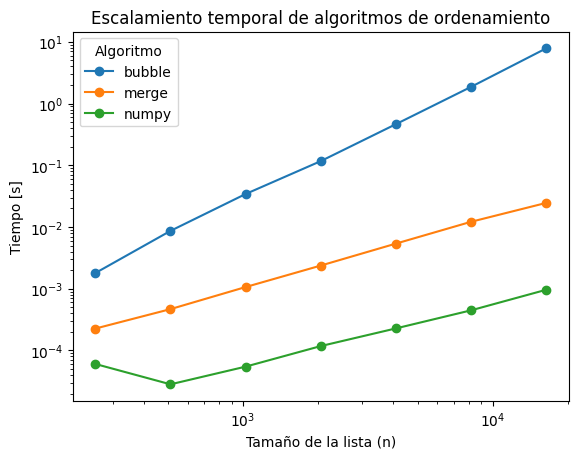

In [339]:
import matplotlib.pyplot as plt

df.plot(marker="o")
plt.loglog()                       # ejes log-log -REMUEVA Y VEA SIN LOG-LOG
plt.xlabel("Tamaño de la lista (n)")
plt.ylabel("Tiempo [s]")
plt.title("Escalamiento temporal de algoritmos de ordenamiento")
plt.legend(title="Algoritmo")
plt.show()

In [371]:
import pandas as pd, numpy as np
np.random.seed(0)
df = pd.DataFrame({
    "nombre":  [f"Star-{i}" for i in range(5000)],
    "mag":     np.random.normal(8, 1.2, 5000).round(2),
    "dist_pc": np.random.exponential(20, 5000).round(1)
})

## 

### 1. ordenar por magnitud

In [367]:
# Más brillante = menor magnitud aparente
df_ordenado = df.sort_values("mag")
top10_bril = df_ordenado.head(10)
print(top10_bril)

         nombre   mag  dist_pc
3752  Star-3752  3.51     10.0
3679  Star-3679  3.93     84.2
2018  Star-2018  4.26     13.0
589    Star-589  4.34      1.3
3462  Star-3462  4.39     16.4
4469  Star-4469  4.39     14.1
1446  Star-1446  4.41      1.8
4337  Star-4337  4.53      6.1
2114  Star-2114  4.60      0.4
685    Star-685  4.60      5.2


### 2. Usar Binary search

In [370]:
# Asegurar que esté ordenado por magnitud
mag_list = df_ordenado["mag"].tolist()

In [369]:
# Buscar magnitud 9.3
pos, steps = binary_search(mag_list, 4.39)
if pos != -1:
    estrella = df_ordenado.iloc[pos]
    print(f"Encontrado: {estrella['nombre']} con mag={estrella['mag']}, dist={estrella['dist_pc']} pc (en {steps} pasos)")
else:
    print("No se encontró una estrella con esa magnitud")

Encontrado: Star-4469 con mag=4.39, dist=14.1 pc (en 11 pasos)


###

### 

In [ ]:

def quick_sort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr)//2]
    left  = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quick_sort(left) + middle + quick_sort(right)

def merge_sort(lst):
    if len(lst) <= 1:
        return lst
    mid = len(lst) // 2
    left  = merge_sort(lst[:mid])
    right = merge_sort(lst[mid:])
    return merge(left, right)

def merge(left, right):
    out, i, j = [], 0, 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            out.append(left[i]); i += 1
        else:
            out.append(right[j]); j += 1
    return out + left[i:] + right[j:]

891 μs ± 76.4 μs per loop (mean ± std. dev. of 3 runs, 1 loop each)
1.38 ms ± 140 μs per loop (mean ± std. dev. of 3 runs, 1 loop each)
5.43 ms ± 561 μs per loop (mean ± std. dev. of 3 runs, 1 loop each)
5.34 ms ± 371 μs per loop (mean ± std. dev. of 3 runs, 1 loop each)
16.3 ms ± 19 μs per loop (mean ± std. dev. of 3 runs, 1 loop each)
22.9 ms ± 236 μs per loop (mean ± std. dev. of 3 runs, 1 loop each)
154 ms ± 25.5 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
229 ms ± 4.03 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


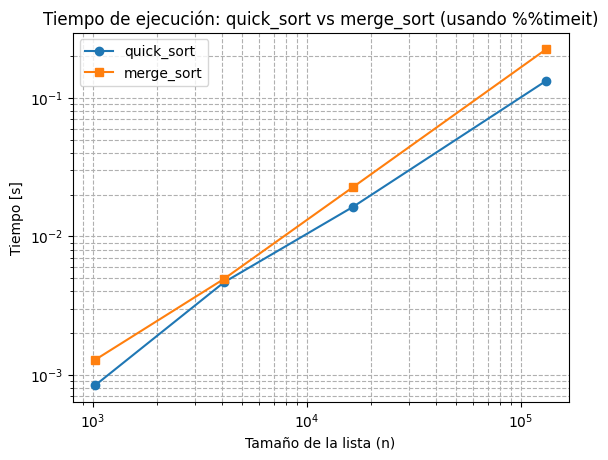

In [463]:
ns = [2**10, 2**12, 2**14,2**17]
quick_times = []
merge_times = []

for n in ns:
    arr = np.random.randint(0, 10000, n).tolist()
    # Quick sort
    qt = %timeit -o -r 3 -n 1 quick_sort(arr.copy())
    quick_times.append(qt.best)
    # Merge sort
    mt = %timeit -o -r 3 -n 1 merge_sort(arr.copy())
    merge_times.append(mt.best)


plt.plot(ns, quick_times, marker='o', label='quick_sort')
plt.plot(ns, merge_times, marker='s', label='merge_sort')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tamaño de la lista (n)')
plt.ylabel('Tiempo [s]')
plt.title('Tiempo de ejecución: quick_sort vs merge_sort (usando %%timeit)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()